# Reproduction - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case

## Load Dataset

In [ ]:
from dataset import Dataset

dataset = Dataset(path="./data/state/ILINet.csv")
train_loader, vali_loader, test_loader = dataset.get_train_val_test_loader()

Train samples: 16052
Validation samples: 1784
Test samples: 4460


## ARIMA - Baseline Part (National)

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.tsa.arima.model import ARIMA

import statsmodels
import logging
logging.getLogger("statsmodels").setLevel(logging.ERROR)

In [6]:
# Load International ILI data
df_national = pd.read_csv("./data/national/ILINet.csv", header=1)
series = df_national["%UNWEIGHTED ILI"].values.astype(float)
 
print(f"Total weeks loaded : {len(series)}")
print(f"ILI range          : {series.min():.3f} ~ {series.max():.3f}")

# Sliding window — must match dataset.py parameters exactly
HISTORY = 10   # Input: Past 10 weeks
FUTURE  = 4    # Outout: 4 weeks
TEST_SIZE = 0.2

X, Y = [], []
for i in range(len(series) - HISTORY - FUTURE):
    X.append(series[i : i + HISTORY])
    Y.append(series[i + HISTORY : i + HISTORY + FUTURE])

X = np.array(X)  # (n_samples, 10)
Y = np.array(Y)  # (n_samples, 4)

split_idx = int(len(X) * (1 - TEST_SIZE))
X_test = X[split_idx:]
Y_test = Y[split_idx:]

print(f"\nTotal sliding windows : {len(X)}")
print(f"Test set size         : {len(X_test)} windows")
print(f"Each window           : {HISTORY} weeks in -> {FUTURE} weeks out")


Total weeks loaded : 417
ILI range          : 0.645 ~ 7.798

Total sliding windows : 403
Test set size         : 81 windows
Each window           : 10 weeks in -> 4 weeks out


In [7]:
def arima_predict_window(history_window, order=(3, 0, 3), steps=4):
    """
    Given a history window of length HISTORY, forecast the next `steps` values.
 
    Paper setting: ARIMA(3, 0, 3) with constant trend, order chosen by AIC/BIC.
 
    Args:
        history_window : np.array of shape (HISTORY,)
        order          : (p, d, q) tuple
        steps          : number of future steps to forecast
    Returns:
        np.array of shape (steps,)
    """
    try:
        model = ARIMA(history_window, order=order, trend="c")
        fit   = model.fit(method_kwargs={"maxiter": 200})
        return fit.forecast(steps=steps)
    except Exception:
        # Fallback: repeat the last observed value if fitting fails
        return np.full(steps, history_window[-1])
 
 
print("Running ARIMA(3,0,3) predictions...")
all_preds = []
 
for i, window in enumerate(X_test):
    pred = arima_predict_window(window, order=(3, 0, 3), steps=FUTURE)
    all_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(X_test)} windows done...")
 
all_preds  = np.array(all_preds)   # shape: (n_test, 4)
all_labels = Y_test                 # shape: (n_test, 4)
print("Done!")

Running ARIMA(3,0,3) predictions...
  10/81 windows done...
  20/81 windows done...
  30/81 windows done...
  40/81 windows done...
  50/81 windows done...
  60/81 windows done...
  70/81 windows done...


/Users/linglinshuai/Desktop/ECE228/project/epidemic-transformer-forecasting/venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  80/81 windows done...
Done!


In [8]:
print("\n" + "="*50)
print("  ARIMA(3,0,3) Baseline Results")
print("="*50)
 
arima_metrics = {}
for step in range(FUTURE):
    p  = all_preds[:, step]
    l  = all_labels[:, step]
    rmse       = np.sqrt(np.mean((p - l) ** 2))
    mae        = np.mean(np.abs(p - l))
    pearson, _ = pearsonr(p, l)
    print(f"  Week+{step+1}: RMSE={rmse:.4f}  MAE={mae:.4f}  Pearson={pearson:.4f}")
    arima_metrics[f"week{step+1}"] = {"rmse": rmse, "mae": mae, "pearson": pearson}
 
# Overall metrics (flatten all steps)
p_all          = all_preds.flatten()
l_all          = all_labels.flatten()
overall_rmse    = np.sqrt(np.mean((p_all - l_all) ** 2))
overall_mae     = np.mean(np.abs(p_all - l_all))
overall_pearson, _ = pearsonr(p_all, l_all)
 
print("-"*50)
print(f"  Overall : RMSE={overall_rmse:.4f}  MAE={overall_mae:.4f}  Pearson={overall_pearson:.4f}")
print("="*50)
print("\n-> This is the baseline. The Transformer should beat these numbers!")
 
arima_metrics["overall"] = {
    "rmse": overall_rmse, "mae": overall_mae, "pearson": overall_pearson
}


  ARIMA(3,0,3) Baseline Results
  Week+1: RMSE=0.4107  MAE=0.2638  Pearson=0.9740
  Week+2: RMSE=0.9627  MAE=0.5991  Pearson=0.8566
  Week+3: RMSE=1.5317  MAE=0.9562  Pearson=0.6511
  Week+4: RMSE=1.9712  MAE=1.2809  Pearson=0.4531
--------------------------------------------------
  Overall : RMSE=1.3534  MAE=0.7750  Pearson=0.7254

-> This is the baseline. The Transformer should beat these numbers!


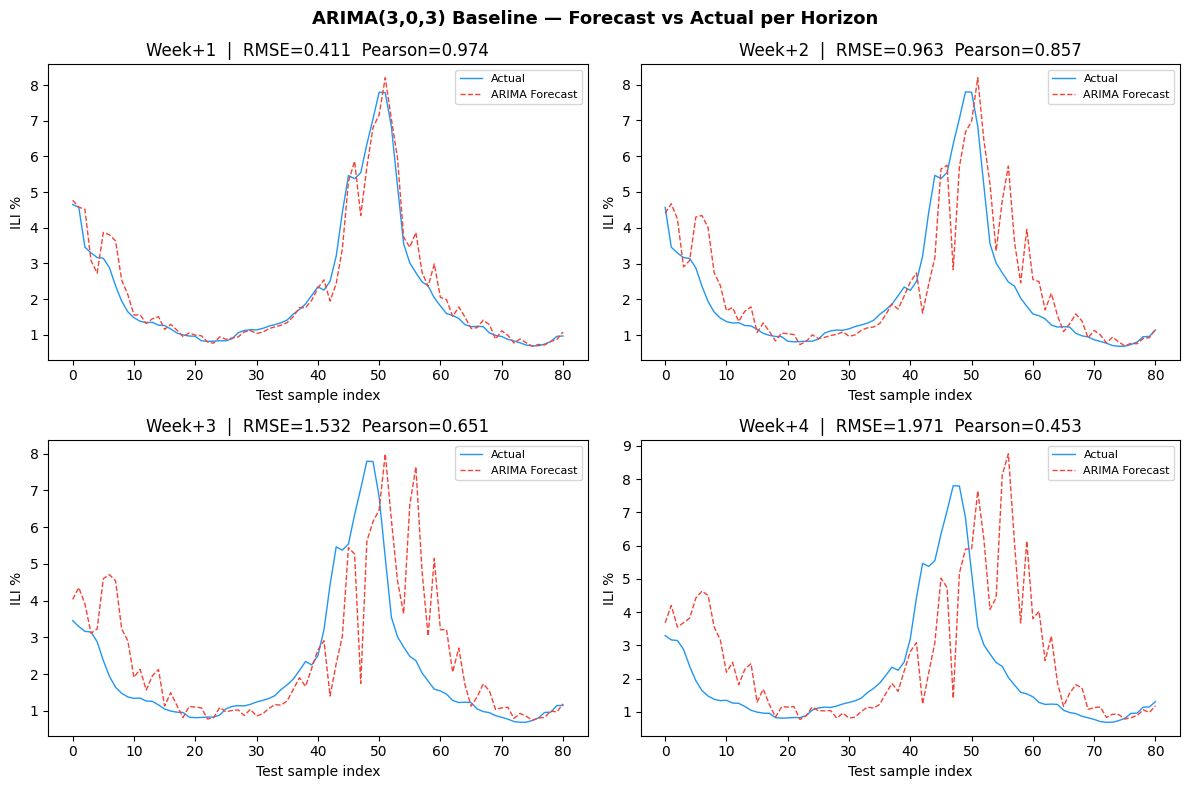

Plot saved: arima_baseline_results.png
Saved:
  arima_preds.npy   — ARIMA predictions, shape (n_test, 4)
  arima_labels.npy  — Ground truth labels, shape (n_test, 4)

Load these later to compare directly with Transformer results.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("ARIMA(3,0,3) Baseline — Forecast vs Actual per Horizon",
             fontsize=13, fontweight="bold")
 
for step in range(FUTURE):
    ax   = axes[step // 2][step % 2]
    rmse = arima_metrics[f"week{step+1}"]["rmse"]
    r    = arima_metrics[f"week{step+1}"]["pearson"]
 
    ax.plot(all_labels[:, step], color="#2196F3", linewidth=1.0, label="Actual")
    ax.plot(all_preds[:, step],  color="#F44336", linewidth=1.0,
            linestyle="--", label="ARIMA Forecast")
    ax.set_title(f"Week+{step+1}  |  RMSE={rmse:.3f}  Pearson={r:.3f}")
    ax.set_ylabel("ILI %")
    ax.set_xlabel("Test sample index")
    ax.legend(fontsize=8)
 
plt.tight_layout()
plt.savefig("arima_baseline_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: arima_baseline_results.png")
 

 
np.save("arima_preds.npy",  all_preds)
np.save("arima_labels.npy", all_labels)
print("Saved:")
print("  arima_preds.npy   — ARIMA predictions, shape (n_test, 4)")
print("  arima_labels.npy  — Ground truth labels, shape (n_test, 4)")
print("\nLoad these later to compare directly with Transformer results.")

## Persistence Forecasting - Baseline Part (Nationl)

In [8]:
# ── Cell 1: Persistence Prediction ───────────────────────────

def persistence_predict(X_test, steps=4):
    """
    Persistence forecasting: repeat the last observed value for all future steps.

    This is the simplest possible baseline — if a model cannot beat this,
    it has no practical value.

    Args:
        X_test : np.array of shape (n_test, HISTORY)
        steps  : number of future steps to forecast
    Returns:
        np.array of shape (n_test, steps)
    """
    # Last value of each history window, repeated `steps` times
    last_values = X_test[:, -1]                     # shape: (n_test,)
    preds       = np.tile(last_values, (steps, 1)).T # shape: (n_test, steps)
    return preds

persist_preds  = persistence_predict(X_test, steps=FUTURE)
persist_labels = Y_test   # same ground truth as ARIMA

print("Persistence forecasting done!")
print(f"Predictions shape : {persist_preds.shape}")

Persistence forecasting done!
Predictions shape : (81, 4)


In [9]:
# ── Cell 2: Evaluate ─────────────────────────────────────────

print("\n" + "="*50)
print("  Persistence Baseline Results")
print("="*50)

persist_metrics = {}
for step in range(FUTURE):
    p  = persist_preds[:, step]
    l  = persist_labels[:, step]
    rmse       = np.sqrt(np.mean((p - l) ** 2))
    mae        = np.mean(np.abs(p - l))
    pearson, _ = pearsonr(p, l)
    print(f"  Week+{step+1}: RMSE={rmse:.4f}  MAE={mae:.4f}  Pearson={pearson:.4f}")
    persist_metrics[f"week{step+1}"] = {"rmse": rmse, "mae": mae, "pearson": pearson}

# Overall metrics
p_all          = persist_preds.flatten()
l_all          = persist_labels.flatten()
overall_rmse       = np.sqrt(np.mean((p_all - l_all) ** 2))
overall_mae        = np.mean(np.abs(p_all - l_all))
overall_pearson, _ = pearsonr(p_all, l_all)

print("-"*50)
print(f"  Overall : RMSE={overall_rmse:.4f}  MAE={overall_mae:.4f}  Pearson={overall_pearson:.4f}")
print("="*50)

persist_metrics["overall"] = {
    "rmse": overall_rmse, "mae": overall_mae, "pearson": overall_pearson
}


  Persistence Baseline Results
  Week+1: RMSE=0.4185  MAE=0.2314  Pearson=0.9726
  Week+2: RMSE=0.7746  MAE=0.4528  Pearson=0.9054
  Week+3: RMSE=1.0736  MAE=0.6595  Pearson=0.8169
  Week+4: RMSE=1.3150  MAE=0.8485  Pearson=0.7243
--------------------------------------------------
  Overall : RMSE=0.9562  MAE=0.5480  Pearson=0.8553


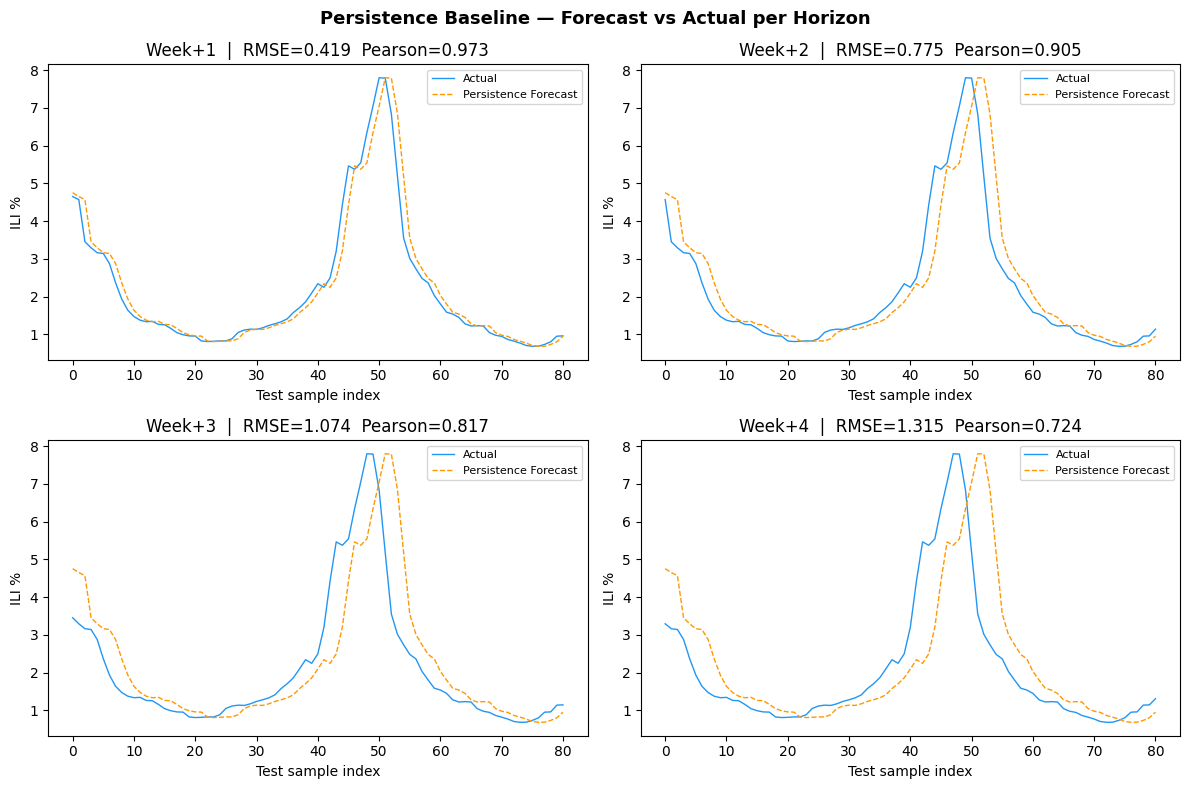

Plot saved: persistence_baseline_results.png
Saved: persistence_preds.npy
Labels already saved as arima_labels.npy — shared across all baselines.


In [ ]:


# ───────────── Visualize ────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Persistence Baseline — Forecast vs Actual per Horizon",
             fontsize=13, fontweight="bold")

for step in range(FUTURE):
    ax   = axes[step // 2][step % 2]
    rmse = persist_metrics[f"week{step+1}"]["rmse"]
    r    = persist_metrics[f"week{step+1}"]["pearson"]

    ax.plot(persist_labels[:, step], color="#2196F3", linewidth=1.0, label="Actual")
    ax.plot(persist_preds[:, step],  color="#FF9800", linewidth=1.0,
            linestyle="--", label="Persistence Forecast")
    ax.set_title(f"Week+{step+1}  |  RMSE={rmse:.3f}  Pearson={r:.3f}")
    ax.set_ylabel("ILI %")
    ax.set_xlabel("Test sample index")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("persistence_baseline_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: persistence_baseline_results.png")


# ────────── Save results ─────────────────────────────────────

np.save("persistence_preds.npy", persist_preds)
print("Saved: persistence_preds.npy")
print("Labels already saved as arima_labels.npy — shared across all baselines.")


  Model                    RMSE      MAE    Pearson
  Week+1 ARIMA          0.4107   0.2638     0.9740
  Week+1 Persistence    0.4185   0.2314     0.9726
  --------------------------------------------------------
  Week+2 ARIMA          0.9627   0.5991     0.8566
  Week+2 Persistence    0.7746   0.4528     0.9054
  --------------------------------------------------------
  Week+3 ARIMA          1.5317   0.9562     0.6511
  Week+3 Persistence    1.0736   0.6595     0.8169
  --------------------------------------------------------
  Week+4 ARIMA          1.9712   1.2809     0.4531
  Week+4 Persistence    1.3150   0.8485     0.7243
  --------------------------------------------------------
  Overall ARIMA          1.3534   0.7750     0.7254
  Overall Persistence    0.9562   0.5480     0.8553


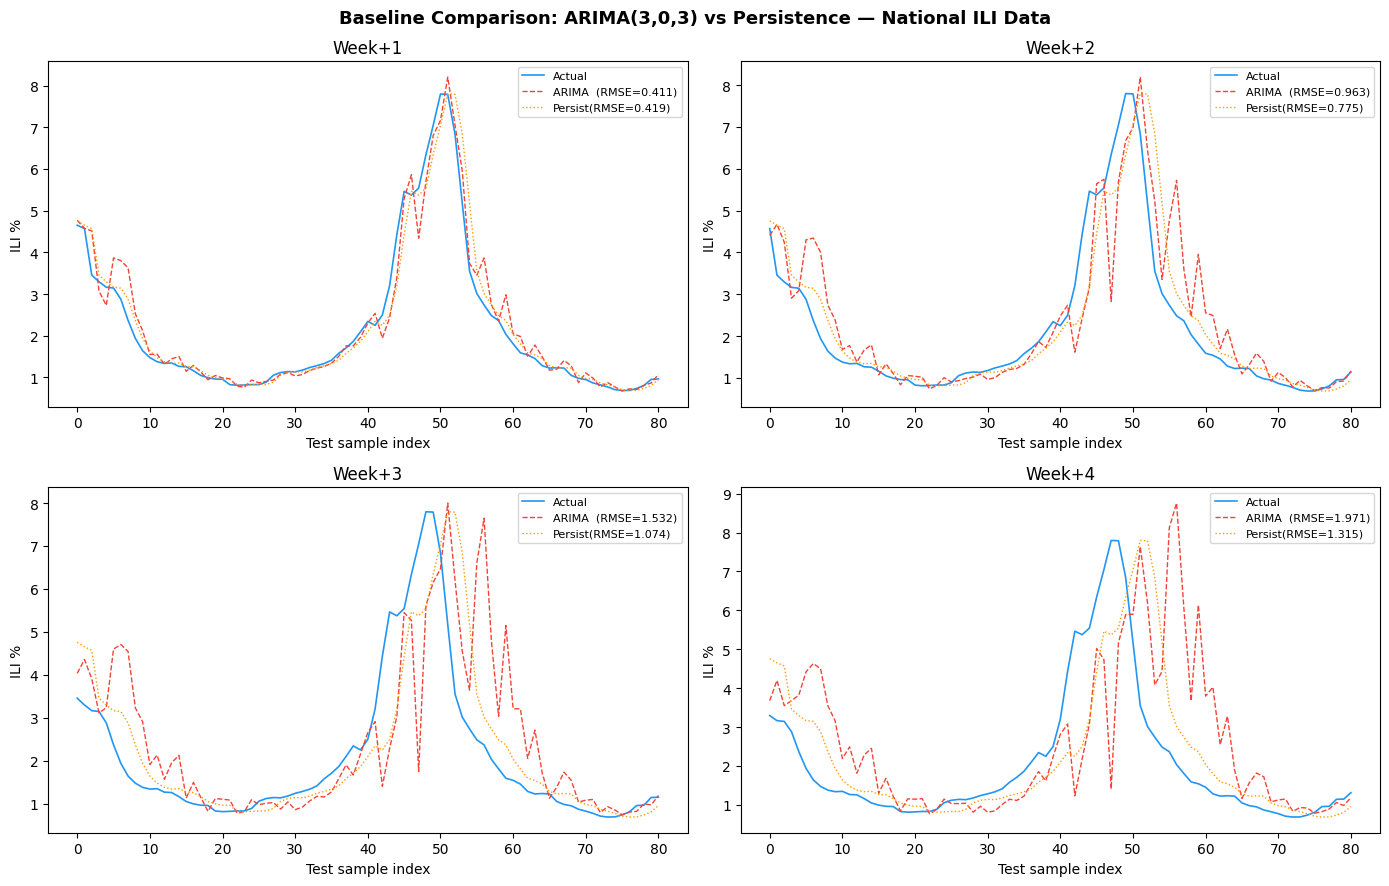

Plot saved: baseline_comparison.png


In [ ]:
# ── Combined Comparison: ARIMA vs Persistence ────────────────

print("\n" + "="*60)
print(f"  {'Model':<20} {'RMSE':>8} {'MAE':>8} {'Pearson':>10}")
print("="*60)
for step in range(FUTURE):
    a = arima_metrics[f"week{step+1}"]
    p = persist_metrics[f"week{step+1}"]
    print(f"  Week+{step+1} ARIMA        {a['rmse']:>8.4f} {a['mae']:>8.4f} {a['pearson']:>10.4f}")
    print(f"  Week+{step+1} Persistence  {p['rmse']:>8.4f} {p['mae']:>8.4f} {p['pearson']:>10.4f}")
    print(f"  {'-'*56}")
a = arima_metrics["overall"]
p = persist_metrics["overall"]
print(f"  {'Overall ARIMA':<20} {a['rmse']:>8.4f} {a['mae']:>8.4f} {a['pearson']:>10.4f}")
print(f"  {'Overall Persistence':<20} {p['rmse']:>8.4f} {p['mae']:>8.4f} {p['pearson']:>10.4f}")
print("="*60)



fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Baseline Comparison: ARIMA(3,0,3) vs Persistence — National ILI Data",
             fontsize=13, fontweight="bold")

for step in range(FUTURE):
    ax = axes[step // 2][step % 2]

    # Ground truth
    ax.plot(all_labels[:, step],
            color="#2196F3", linewidth=1.2,
            label="Actual")

    # ARIMA
    ax.plot(all_preds[:, step],
            color="#F44336", linewidth=1.0, linestyle="--",
            label=f"ARIMA  (RMSE={arima_metrics[f'week{step+1}']['rmse']:.3f})")

    # Persistence
    ax.plot(persist_preds[:, step],
            color="#FF9800", linewidth=1.0, linestyle=":",
            label=f"Persist(RMSE={persist_metrics[f'week{step+1}']['rmse']:.3f})")

    ax.set_title(f"Week+{step+1}")
    ax.set_ylabel("ILI %")
    ax.set_xlabel("Test sample index")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: baseline_comparison.png")

## Persistence Forecasting - State

In [10]:
import pandas as pd
df_state = pd.read_csv("./data/state/ILINet.csv", header=1)

print(df_state["REGION"].unique())        # 有哪些州？
print(f"Total rows: {len(df_state)}")
print(f"Weeks per state: {df_state.groupby('REGION').size().unique()}")
print(df_state[df_state["REGION"] == "Alabama"].head(5)[["YEAR", "WEEK", "%UNWEIGHTED ILI"]])

['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming' 'New York City'
 'Virgin Islands' 'Puerto Rico']
Total rows: 22310
Weeks per state: [417 261 365]
     YEAR  WEEK  %UNWEIGHTED ILI
0    2010    40          2.13477
52   2010    41          2.05999
104  2010    42          1.94224
156  2010    43          2.27650
208  2010    44          2.83371


In [ ]:
print(df_state.groupby("REGION").size().sort_values())

Persistence baseline done for 54 states!

State                        W+1    W+2    W+3    W+4 |    W+1    W+2    W+3    W+4 |    W+1    W+2    W+3    W+4
                                 --- RMSE ---         |         --- MAE ---         |       --- Pearson ---      
-----------------------------------------------------------------------------------------------
  Alabama                  0.943  1.530  2.076  2.617 | 0.491  0.820  1.209  1.548 | 0.957  0.886  0.789  0.663
  Alaska                   0.658  0.866  1.084  1.244 | 0.507  0.710  0.871  0.998 | 0.939  0.894  0.834  0.782
  Arizona                  0.538  0.774  0.978  1.141 | 0.376  0.514  0.615  0.718 | 0.931  0.856  0.771  0.689
  Arkansas                 1.061  1.579  2.002  2.443 | 0.671  0.952  1.147  1.454 | 0.939  0.862  0.774  0.661
  California               0.426  0.715  0.891  0.999 | 0.228  0.384  0.471  0.570 | 0.937  0.822  0.723  0.653
  Colorado                 0.421  0.464  0.539  0.631 | 0.263  0.343  0.38

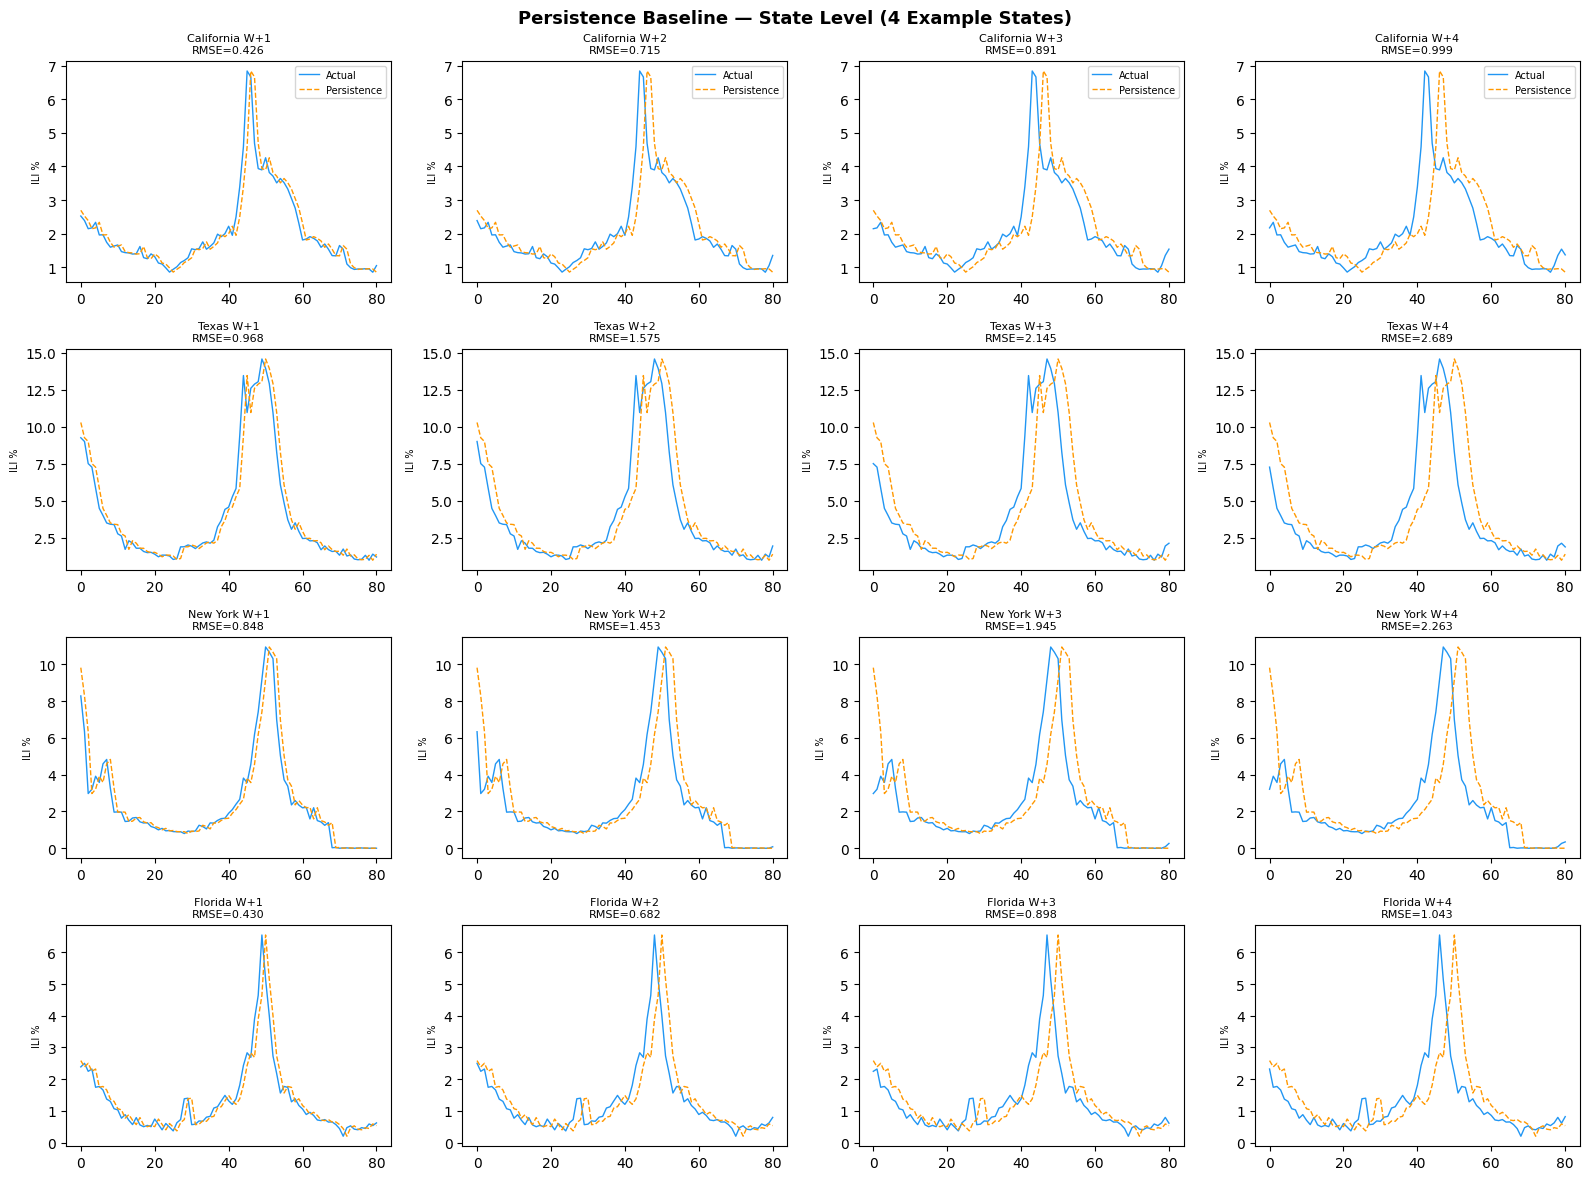

Plot saved: state_persistence_results.png
Saved: state_persist_results.pkl
Load later with: import pickle; results = pickle.load(open('state_persist_results.pkl','rb'))


In [14]:
import numpy as np
# ============================================================
# Persistence Baseline — State Level
# ============================================================

df_state = pd.read_csv("./data/state/ILINet.csv", header=1)

# Use all states regardless of data length
all_states = df_state["REGION"].unique().tolist()

# ── Cell 2: Run Persistence per state ────────────────────────

HISTORY   = 10
FUTURE    = 4
TEST_SIZE = 0.2

state_persist_results = {}
# Structure: { state_name: { "preds": (81,4), "labels": (81,4), "metrics": {...} } }

for state in all_states:
    # Extract & sort this state's time series
    series = (
        df_state[df_state["REGION"] == state]
        .sort_values(["YEAR", "WEEK"])
        ["%UNWEIGHTED ILI"]
        .values.astype(float)
    )

    # Sliding window
    X, Y = [], []
    for i in range(len(series) - HISTORY - FUTURE):
        X.append(series[i : i + HISTORY])
        Y.append(series[i + HISTORY : i + HISTORY + FUTURE])
    X, Y = np.array(X), np.array(Y)

    # Test split
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_test = X[split_idx:]
    Y_test = Y[split_idx:]

    # Persistence: repeat last observed value
    last_values = X_test[:, -1]                      # shape: (81,)
    preds       = np.tile(last_values, (FUTURE, 1)).T # shape: (81, 4)

    # Compute metrics per horizon
    metrics = {}
    for step in range(FUTURE):
        p  = preds[:, step]
        l  = Y_test[:, step]
        rmse       = np.sqrt(np.mean((p - l) ** 2))
        mae        = np.mean(np.abs(p - l))
        pearson, _ = pearsonr(p, l)
        metrics[f"week{step+1}"] = {"rmse": rmse, "mae": mae, "pearson": pearson}

    # Overall metrics
    p_all          = preds.flatten()
    l_all          = Y_test.flatten()
    overall_rmse       = np.sqrt(np.mean((p_all - l_all) ** 2))
    overall_mae        = np.mean(np.abs(p_all - l_all))
    overall_pearson, _ = pearsonr(p_all, l_all)
    metrics["overall"] = {"rmse": overall_rmse, "mae": overall_mae, "pearson": overall_pearson}

    # Store everything
    state_persist_results[state] = {
        "preds":   preds,
        "labels":  Y_test,
        "metrics": metrics
    }

print(f"Persistence baseline done for {len(state_persist_results)} states!")


# ── Cell 3: Print results table ───────────────────────────────

print(f"\n{'State':<25} {'W+1':>6} {'W+2':>6} {'W+3':>6} {'W+4':>6} | {'W+1':>6} {'W+2':>6} {'W+3':>6} {'W+4':>6} | {'W+1':>6} {'W+2':>6} {'W+3':>6} {'W+4':>6}")
print(f"{'':25} {'--- RMSE ---':^27} | {'--- MAE ---':^27} | {'--- Pearson ---':^27}")
print("-" * 95)

for state in all_states:
    m = state_persist_results[state]["metrics"]
    print(
        f"  {state:<23}"
        f"  {m['week1']['rmse']:>5.3f}  {m['week2']['rmse']:>5.3f}  {m['week3']['rmse']:>5.3f}  {m['week4']['rmse']:>5.3f}"
        f" | {m['week1']['mae']:>5.3f}  {m['week2']['mae']:>5.3f}  {m['week3']['mae']:>5.3f}  {m['week4']['mae']:>5.3f}"
        f" | {m['week1']['pearson']:>5.3f}  {m['week2']['pearson']:>5.3f}  {m['week3']['pearson']:>5.3f}  {m['week4']['pearson']:>5.3f}"
    )


# ── Cell 4: Visualize — pick 4 example states ────────────────

example_states = ["California", "Texas", "New York", "Florida"]

fig, axes = plt.subplots(len(example_states), FUTURE, figsize=(16, 12))
fig.suptitle("Persistence Baseline — State Level (4 Example States)",
             fontsize=13, fontweight="bold")

for row, state in enumerate(example_states):
    preds  = state_persist_results[state]["preds"]
    labels = state_persist_results[state]["labels"]
    for step in range(FUTURE):
        ax = axes[row][step]
        ax.plot(labels[:, step], color="#2196F3", linewidth=1.0, label="Actual")
        ax.plot(preds[:, step],  color="#FF9800", linewidth=1.0,
                linestyle="--", label="Persistence")
        rmse = state_persist_results[state]["metrics"][f"week{step+1}"]["rmse"]
        ax.set_title(f"{state} W+{step+1}\nRMSE={rmse:.3f}", fontsize=8)
        ax.set_ylabel("ILI %", fontsize=7)
        if row == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("state_persistence_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: state_persistence_results.png")


# ── Cell 5: Save results ─────────────────────────────────────

import pickle
with open("state_persist_results.pkl", "wb") as f:
    pickle.dump(state_persist_results, f)

print("Saved: state_persist_results.pkl")
print("Load later with: import pickle; results = pickle.load(open('state_persist_results.pkl','rb'))")

## Deep Transformer Model

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import matplotlib.pyplot as plt


class DeepTransformer:
    pass

In [32]:
class PipeLine:
    def __init__(self, model, train_loader, val_loader, warmup_steps=5000, d_model=64):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.d_model = d_model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.warmup_steps = warmup_steps
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            betas=(0.9, 0.98),
            eps=1e-9
        )
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(
            self.optimizer,
            lr_lambda=self.lr_lambda
        )
        self.loss_func = nn.MSELoss()

    def lr_lambda(self, step):
        step = max(step, 1)
        lr = (self.d_model ** (-0.5)) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))
        return lr

    def train_model(self, epochs):
        train_losses = []
        val_losses = []
    
        best_val_loss = float("inf")
        best_model = None

        for epoch in range(1, epochs+1):
            train_loss = self.train_one_epoch()
            train_losses.append(train_loss)
    
            val_loss = self.evaluate(self.val_loader)
            val_losses.append(val_loss)
    
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = copy.deepcopy(self.model)
    
            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        return best_model, train_losses, val_losses
    
    def train_one_epoch(self):
        """
        Run one full pass over the training dataloader and return the average loss.
        """
        self.model.train()
        total_loss, total_count = 0.0, 0
        for xb, yb in self.train_loader:
            xb, yb = xb.to(self.device), yb.to(self.device)
            self.optimizer.zero_grad()
    
            pred = None
            pred = self.model(xb)
            loss = self.loss_func(pred, yb)
            loss.backward()
    
            self.optimizer.step()
            self.scheduler.step()
            total_loss  += loss.item() * xb.size(0)
            total_count += xb.size(0)
        return total_loss / total_count

    @torch.no_grad()
    def evaluate(self, dataloader):
        """
        Evaluate the model on valid dataloader without updating weights.
        Returns the average loss.
        """
        self.model.eval()
        total_loss, total_count = 0.0, 0
    
        for xb, yb in dataloader:
            xb, yb = xb.to(self.device), yb.to(self.device)
            pred = self.model(xb)
            loss = self.loss_func(pred, yb)
    
            total_loss  += loss.item() * xb.size(0)
            total_count += xb.size(0)
        return total_loss / total_count

ARIMA - Baseline Part

In [33]:
import pandas as pd
df = pd.read_csv("./data/national/ILINet.csv", header=1)
print(df.columns.tolist())
print(df.head(3))
print(len(df))

['REGION TYPE', 'REGION', 'YEAR', 'WEEK', '% WEIGHTED ILI', '%UNWEIGHTED ILI', 'AGE 0-4', 'AGE 25-49', 'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS']
  REGION TYPE REGION  YEAR  WEEK  % WEIGHTED ILI  %UNWEIGHTED ILI  AGE 0-4  \
0    National      X  2010    40         1.10939          1.13505     2627   
1    National      X  2010    41         1.24341          1.25256     2953   
2    National      X  2010    42         1.25726          1.24570     3044   

   AGE 25-49 AGE 25-64  AGE 5-24  AGE 50-64  AGE 65  ILITOTAL  \
0       1677         X      3142        627     400      8473   
1       1779         X      3522        649     444      9347   
2       1898         X      3641        690     411      9684   

   NUM. OF PROVIDERS  TOTAL PATIENTS  
0               1838          746485  
1               1875          746230  
2               1907          777397  
417


# Improvement - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case